### The Anatomy of a Decorator
At its core, a decorator is a function that takes another function as an argument and returns a replacement function

The Foundation (Scope & Closures)
In Python, functions are **First-Class Citizens**. This means:

   -  You can assign a function to a variable.

   - You can pass a function as an argument.

   - You can define a function inside another function.

**The "Closure"**

A closure is a nested function that "remembers" the variables from its enclosing scope even after the outer function has finished executing.

In [1]:
def power_factory(exp):
    def internal_power(base):
        return base ** exp 
    return internal_power 

square = power_factory(2)
print(square(10))

100


**Why this matters**: Decorators are essentially closures where the "remembered" variable is the function you are wrapping.

#### Phase 2: Building the Decorator from Scratch
A decorator is just a function that takes a function and returns a new one. The `@` symbol is just **syntactic sugar**.

**Manual Decoration (The "Hard" Way)**

In [2]:
def debug(func):
    def wrapper():
        print(f"Calling {func.__name__}")
        func()
    return wrapper

def say_hi():
    print("Hi!")

# Manual decoration:
say_hi = debug(say_hi)
say_hi()

Calling say_hi
Hi!


In [3]:
@debug
def say_hi():
    print("Hi!")

In [4]:
say_hi()

Calling say_hi
Hi!


#### Phase 3: The "Production-Ready" Pattern
When we write real-world decorators, we face two problems:

Arguments: The function we wrap might have 0, 1, or 50 arguments.

Metadata: If you check `say_hi.__name__` after decorating it, it will say `"wrapper"`. That breaks debugging and documentation tools.

We fix this using `*args`, `**kwargs`, and `functools.wraps`.

In [5]:
from functools import wraps

def master_decorator(func):
    @wraps(func) # Preserves identity: say_hi remains say_hi
    def wrapper(*args, **kwargs):
        # 1. Do something BEFORE the function
        print("Setup logic here...")
        
        result = func(*args, **kwargs) # 2. Execute the actual function
        
        # 3. Do something AFTER the function
        print("Teardown logic here...")
        
        return result # 4. Return the result so the caller gets it
    return wrapper

In [6]:
@master_decorator
def say_hi():
    print("Hi")

In [7]:
say_hi()

Setup logic here...
Hi
Teardown logic here...


#### Phase 4: Mastery - Decorators with State
Sometimes you need a decorator to "carry" data. For example, a decorator that limits how many times a function can be called.

In [8]:
def limit_calls(max_calls):
    def decorator(func):
        count = 0 # This state persists in the closure!
        
        @wraps(func)
        def wrapper(*args, **kwargs):
            nonlocal count
            if count >= max_calls:
                raise RuntimeError(f"{func.__name__} has exceeded call limit!")
            count += 1
            return func(*args, **kwargs)
        return wrapper
    return decorator

@limit_calls(3)
def sensitive_operation():
    print("Operation performed.")

sensitive_operation() # 1
sensitive_operation() # 2
sensitive_operation() # 3
# sensitive_operation() # This would raise RuntimeError

Operation performed.
Operation performed.
Operation performed.


In [9]:
sensitive_operation()

RuntimeError: sensitive_operation has exceeded call limit!

#### Level: Advanced Intermediate
*The Task: The "Safe-Execution" Decorator*

Create a decorator called `@trace_errors(logfile="errors.txt")`.

It should accept a filename as an argument.

It should wrap a function in a try...except block.

If the function fails, it should catch the exception, write the timestamp and the error message to the `logfile`, and then **re-raise** the error (don't swallow it!).

If it succeeds, it should just return the result.

In [22]:
import datetime
from functools import wraps

def trace_errors(logfile="errors.txt"):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            try:
                # Correctly passing arguments
                return func(*args, **kwargs)
            except Exception as e:
                # Use 'a' for append so we don't lose history
                with open(logfile, "a") as f:
                    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                    f.write(f"[{timestamp}] Error in {func.__name__}: {str(e)}\n")
                
                # CRITICAL: Re-raise the error!
                raise 
        return wrapper
    return decorator

In [23]:
@trace_errors("error.log")
def return_error():
    raise ValueError("Just testing things")

In [24]:
return_error()

ValueError: Just testing things

![WhatsApp Image 2026-04-25 at 17.49.09.jpeg](<attachment:WhatsApp Image 2026-04-25 at 17.49.09.jpeg>)
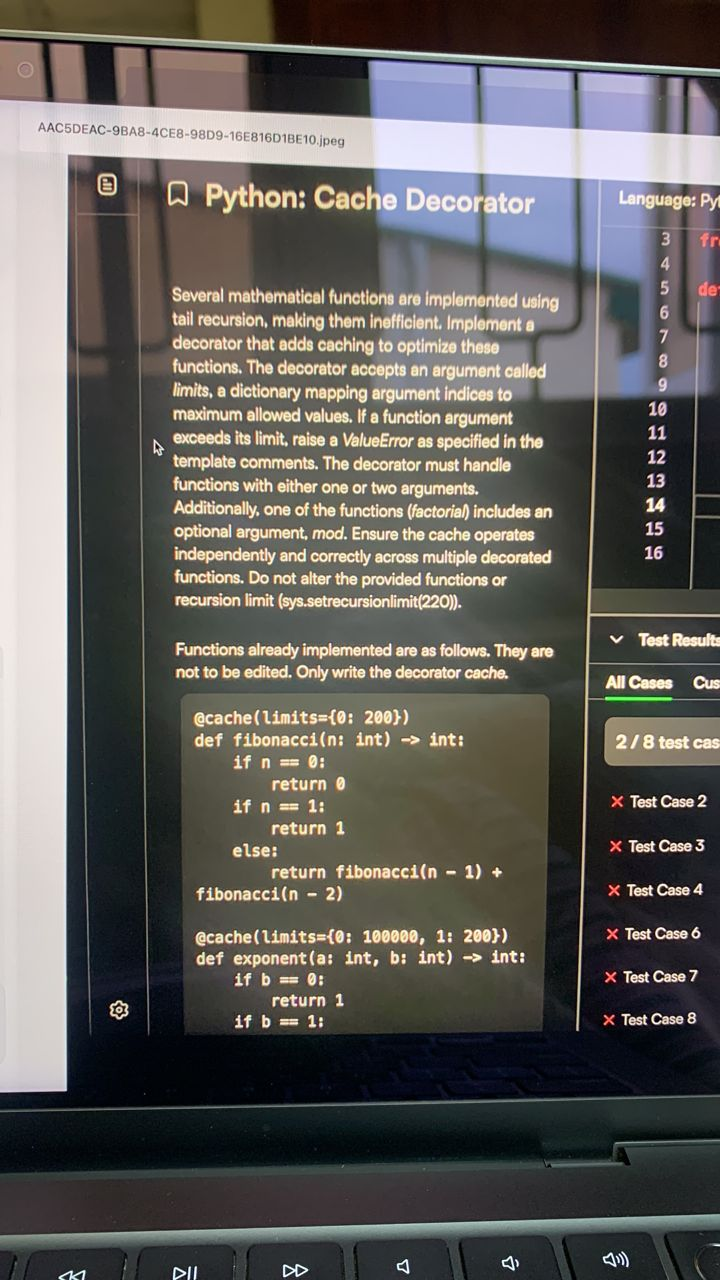

In [28]:
from functools import wraps

def cache(limits: dict):
    def decorator(func):

        storage = {}

        @wraps(func)
        def wrapper(*args, **kwargs):
            for index, value in limits.items():
                if index < len(args) and args[index] > value:
                    raise ValueError(f"Argument {args[index]} at index {index} exceeds limit")

            key = (args, tuple(sorted(kwargs.items())))
            if key not in storage:
                storage[key] = func(*args, **kwargs)

            return storage[key]

        return wrapper
    return decorator


@cache(limits={0: 200})
def fibonacci(n: int) -> int:
    if n == 0:
        return 0
    if n == 1:
        return 1 
    else:
        return fibonacci(n-1)

    
fibonacci(5)

1

In [29]:
from functools import wraps

def cache(limits: dict):
    def decorator(func):
        storage = {}

        @wraps(func)
        def wrapper(*args, **kwargs):
            # Mastery Tip: Combine args and kwargs to check limits properly
            # We check positional args first
            for index, limit_val in limits.items():
                if index < len(args) and args[index] > limit_val:
                    raise ValueError(f"Argument exceeds limit")
            
            # 1. Logic for Caching
            key = (args, tuple(sorted(kwargs.items())))
            if key not in storage:
                storage[key] = func(*args, **kwargs)

            return storage[key]

        return wrapper
    return decorator

@cache(limits={0: 200})
def fibonacci(n: int) -> int:
    if n == 0:
        return 0 # Fixed 'o' to 0
    if n == 1:
        return 1 
    else:
        # Fixed the mathematical formula
        return fibonacci(n-1) + fibonacci(n-2)

print(fibonacci(5)) # Output: 5

5


In [30]:
fibonacci(202)

ValueError: Argument exceeds limit

In [31]:
fibonacci.__closure__[0].cell_contents

<function __main__.fibonacci(n: int) -> int>

In [32]:
from functools import wraps
import time

def cache(limits: dict):
    def decorator(func):
        storage = {}

        @wraps(func)
        def wrapper(*args, **kwargs):

            # -----------------------------
            # 1. LIMIT CHECKING
            # -----------------------------
            for index, limit_val in limits.items():
                if index < len(args) and args[index] > limit_val:
                    raise ValueError(f"Argument exceeds limit")

            # -----------------------------
            # 2. CACHE KEY
            # -----------------------------
            key = (args, tuple(sorted(kwargs.items())))

            # -----------------------------
            # 3. CACHE HIT / MISS + TIMING
            # -----------------------------
            if key in storage:
                print(f"⚡ Cache HIT for {func.__name__}{args}")
                return storage[key]

            print(f"🐢 Cache MISS for {func.__name__}{args} — computing...")

            start = time.time()

            result = func(*args, **kwargs)

            end = time.time()

            storage[key] = result

            print(f"✅ Computed in {end - start:.6f} seconds")

            return result

        return wrapper
    return decorator

In [33]:
@cache(limits={0: 200})
def fibonacci(n: int) -> int:
    if n == 0:
        return 0 # Fixed 'o' to 0
    if n == 1:
        return 1 
    else:
        # Fixed the mathematical formula
        return fibonacci(n-1) + fibonacci(n-2)

print(fibonacci(5)) # Output: 5

🐢 Cache MISS for fibonacci(5,) — computing...
🐢 Cache MISS for fibonacci(4,) — computing...
🐢 Cache MISS for fibonacci(3,) — computing...
🐢 Cache MISS for fibonacci(2,) — computing...
🐢 Cache MISS for fibonacci(1,) — computing...
✅ Computed in 0.000000 seconds
🐢 Cache MISS for fibonacci(0,) — computing...
✅ Computed in 0.000000 seconds
✅ Computed in 0.001001 seconds
⚡ Cache HIT for fibonacci(1,)
✅ Computed in 0.001001 seconds
⚡ Cache HIT for fibonacci(2,)
✅ Computed in 0.001001 seconds
⚡ Cache HIT for fibonacci(3,)
✅ Computed in 0.001001 seconds
5


In [38]:
@cache(limits={0: 2000})
def fibonacci(n: int) -> int:
    if n == 0:
        return 0 # Fixed 'o' to 0
    if n == 1:
        return 1 
    else:
        # Fixed the mathematical formula
        return fibonacci(n-1) + fibonacci(n-2)

print(fibonacci(5)) # Output: 5

🐢 Cache MISS for fibonacci(5,) — computing...
🐢 Cache MISS for fibonacci(4,) — computing...
🐢 Cache MISS for fibonacci(3,) — computing...
🐢 Cache MISS for fibonacci(2,) — computing...
🐢 Cache MISS for fibonacci(1,) — computing...
✅ Computed in 0.000000 seconds
🐢 Cache MISS for fibonacci(0,) — computing...
✅ Computed in 0.000000 seconds
✅ Computed in 0.000000 seconds
⚡ Cache HIT for fibonacci(1,)
✅ Computed in 0.000000 seconds
⚡ Cache HIT for fibonacci(2,)
✅ Computed in 0.001149 seconds
⚡ Cache HIT for fibonacci(3,)
✅ Computed in 0.001149 seconds
5
